<a href="https://colab.research.google.com/github/OmarAbouraia/MNIST-Classification-ML/blob/main/Phase1_MNIST_Binary_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [68]:
# =========================
# 1. Imports and Setup lel libraries
# =========================
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from collections import Counter

from tensorflow.keras.datasets import mnist

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.decomposition import PCA
from skimage.feature import hog

import warnings
warnings.filterwarnings("ignore")

# random stata variable 3shan nstkhdmo fel model 3latool
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries imported successfully.")

Libraries imported successfully.


In [69]:
# =========================
# 2. Problem Definition
# =========================

print("Phase 1 Problem Definition")
print("Binary image classification using MNIST.")
print("Selected classes: digit 3 vs digit 8")
print("Input: 28x28 grayscale image")
print("Output: binary label (0 for digit 3, 1 for digit 8)")

Phase 1 Problem Definition
Binary image classification using MNIST.
Selected classes: digit 3 vs digit 8
Input: 28x28 grayscale image
Output: binary label (0 for digit 3, 1 for digit 8)


In [70]:
# =========================
# 3. Load MNIST Dataset
# =========================
(X_train_full, y_train_full), (X_test_full, y_test_full) = mnist.load_data()

print("Original training set shape:", X_train_full.shape)
print("Original training labels shape:", y_train_full.shape)
print("Original test set shape:", X_test_full.shape)
print("Original test labels shape:", y_test_full.shape)

Original training set shape: (60000, 28, 28)
Original training labels shape: (60000,)
Original test set shape: (10000, 28, 28)
Original test labels shape: (10000,)


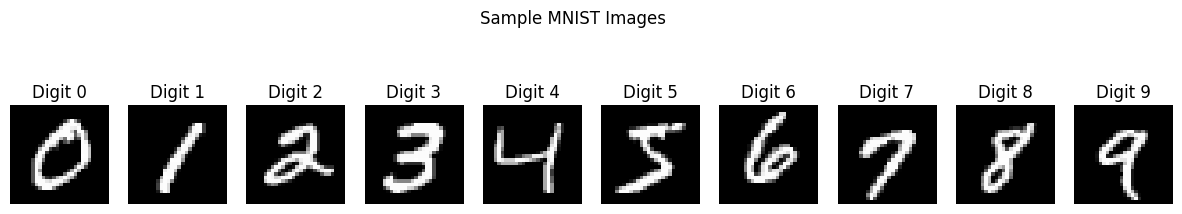

In [71]:
# =========================
# 4. Visualize Sample Images
# =========================
fig, axes = plt.subplots(1, 10, figsize=(15, 3))

for digit in range(10):
    idx = np.where(y_train_full == digit)[0][0]
    axes[digit].imshow(X_train_full[idx], cmap='gray')
    axes[digit].set_title(f"Digit {digit}")
    axes[digit].axis('off')

plt.suptitle("Sample MNIST Images")
plt.show()

In [6]:
# =========================
# 5. Filter lel data Binary Classification (3 vs 8)
# =========================

digit_a = 3
digit_b = 8

# Training Data Filter
train_mask = (y_train_full == digit_a) | (y_train_full == digit_b)
X_train_binary = X_train_full[train_mask]
y_train_binary = y_train_full[train_mask]

# Test Data Filter
test_mask = (y_test_full == digit_a) | (y_test_full == digit_b)
X_test_binary = X_test_full[test_mask]
y_test_binary = y_test_full[test_mask]

# 3 htb2a 0, 8 htb2a 1
y_train_binary = np.where(y_train_binary == digit_a, 0, 1)
y_test_binary = np.where(y_test_binary == digit_a, 0, 1)

print("Filtered training set shape:", X_train_binary.shape)
print("Filtered test set shape:", X_test_binary.shape)

print("\nTraining class distribution:")
print("Class 0 (digit 3):", np.sum(y_train_binary == 0))
print("Class 1 (digit 8):", np.sum(y_train_binary == 1))

print("\nTest class distribution:")
print("Class 0 (digit 3):", np.sum(y_test_binary == 0))
print("Class 1 (digit 8):", np.sum(y_test_binary == 1))

Filtered training set shape: (11982, 28, 28)
Filtered test set shape: (1984, 28, 28)

Training class distribution:
Class 0 (digit 3): 6131
Class 1 (digit 8): 5851

Test class distribution:
Class 0 (digit 3): 1010
Class 1 (digit 8): 974


In [7]:
# =========================
# 6. Normalize and Flatten Images
# =========================

# Normalize pixel values to [0, 1]
X_train_binary = X_train_binary.astype("float32") / 255.0
X_test_binary = X_test_binary.astype("float32") / 255.0

# Flatten 28x28 images into 784-dimensional vectors 3shan nstkhdm el vector fe el models
X_train_flat = X_train_binary.reshape(X_train_binary.shape[0], -1)
X_test_flat = X_test_binary.reshape(X_test_binary.shape[0], -1)

print("Flattened training shape:", X_train_flat.shape)
print("Flattened test shape:", X_test_flat.shape)

Flattened training shape: (11982, 784)
Flattened test shape: (1984, 784)


In [8]:
# =========================
# 7. Train / Validation Split
# =========================

# Split flattened data (for Raw + PCA + Logistic Regression)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_flat,
    y_train_binary,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_train_binary
)

#Split image data (for HOG)
X_train_img, X_val_img, y_train_img, y_val_img = train_test_split(
    X_train_binary,
    y_train_binary,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_train_binary
)

print("Train set shape (flattened):", X_train.shape)
print("Validation set shape (flattened):", X_val.shape)
print("Train set shape (images):", X_train_img.shape)
print("Validation set shape (images):", X_val_img.shape)
print("Test set shape:", X_test_flat.shape)

Train set shape (flattened): (9585, 784)
Validation set shape (flattened): (2397, 784)
Train set shape (images): (9585, 28, 28)
Validation set shape (images): (2397, 28, 28)
Test set shape: (1984, 784)


In [9]:
# =========================
# 8. Feature Scaling
# =========================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test_flat)

print("Feature scaling completed.")

Feature scaling completed.


In [10]:
# =========================
# 9. Evaluation Function
# =========================

def evaluate_model(model, X_data, y_true, dataset_name="Dataset"):
    y_pred = model.predict(X_data)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)

    print(f"\nEvaluation on {dataset_name}")
    print("-" * 40)
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[f"Pred {digit_a}", f"Pred {digit_b}"],
                yticklabels=[f"True {digit_a}", f"True {digit_b}"])
    plt.title(f"Confusion Matrix - {dataset_name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

    return {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1
    }

In [15]:
# =========================
#  PCA Feature Extraction
# =========================

from sklearn.decomposition import PCA

# hnkhtar el number of components
pca = PCA(n_components=50, random_state=RANDOM_STATE)

# Fit on TRAIN ONLY (important)
X_train_pca = pca.fit_transform(X_train_scaled)

# Transform on validation and test
X_val_pca = pca.transform(X_val_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Original dimension:", X_train_scaled.shape[1])
print("Reduced dimension:", X_train_pca.shape[1])

Original dimension: 784
Reduced dimension: 50


In [74]:
# =========================
# HOG Feature Extraction
# =========================

def extract_hog_features(images):
    hog_features = []

    for image in images:
        features = hog(
            image,
            orientations=9,
            pixels_per_cell=(4, 4),
            cells_per_block=(2, 2),
            block_norm='L2-Hys'
        )
        hog_features.append(features)

    return np.array(hog_features)

# Extract HOG features
X_train_hog = extract_hog_features(X_train_img)
X_val_hog = extract_hog_features(X_val_img)
X_test_hog = extract_hog_features(X_test_binary)

print("HOG feature shapes:")
print("Train:", X_train_hog.shape)
print("Validation:", X_val_hog.shape)
print("Test:", X_test_hog.shape)

HOG feature shapes:
Train: (9585, 1296)
Validation: (2397, 1296)
Test: (1984, 1296)


In [75]:
# =========================
# Scale HOG Features
# =========================

hog_scaler = StandardScaler()

X_train_hog_scaled = hog_scaler.fit_transform(X_train_hog)
X_val_hog_scaled = hog_scaler.transform(X_val_hog)
X_test_hog_scaled = hog_scaler.transform(X_test_hog)

print("HOG scaling completed.")

HOG scaling completed.


Iteration 0: Loss = 0.693147
Iteration 100: Loss = 0.100000
Iteration 200: Loss = 0.091994
Iteration 300: Loss = 0.088213
Iteration 400: Loss = 0.085804
Iteration 500: Loss = 0.084060
Iteration 600: Loss = 0.082701
Iteration 700: Loss = 0.081590
Iteration 800: Loss = 0.080653
Iteration 900: Loss = 0.079842
Logistic Regression (from scratch) trained successfully.

Evaluation on Validation Set - Logistic Regression (Raw)
----------------------------------------
Accuracy : 0.9725
Precision: 0.9750
Recall   : 0.9684
F1-score : 0.9717

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.97      1227
           1       0.98      0.97      0.97      1170

    accuracy                           0.97      2397
   macro avg       0.97      0.97      0.97      2397
weighted avg       0.97      0.97      0.97      2397



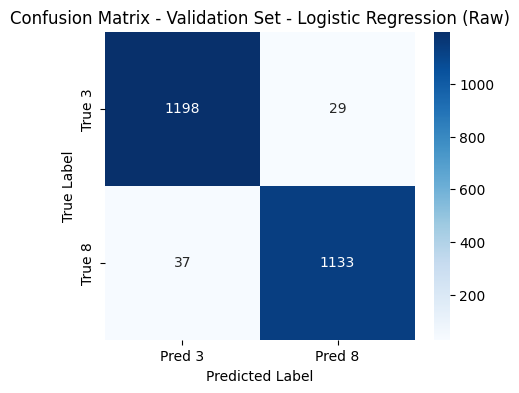

In [90]:
# =========================
# 10. Logistic Regression
# =========================

# ---- hn3rf model "Logistic Regression" w its prarmeters ----
class LogisticRegressionFromScratch:
    def __init__(self, learning_rate=0.1, num_iterations=1000):
        self.learning_rate = learning_rate
        self.num_iterations = num_iterations
        self.weights = None
        self.bias = None
        self.loss_history = []

    def sigmoid(self, z):
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    def compute_loss(self, y_true, y_pred):
        epsilon = 1e-9
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
        return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

    def fit(self, X, y):
        n_samples, n_features = X.shape

        self.weights = np.zeros(n_features)
        self.bias = 0.0

        for i in range(self.num_iterations):
            linear_model = np.dot(X, self.weights) + self.bias
            y_pred = self.sigmoid(linear_model)

            dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))
            db = (1 / n_samples) * np.sum(y_pred - y)

            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            loss = self.compute_loss(y, y_pred)
            self.loss_history.append(loss)

            if i % 100 == 0:
                print(f"Iteration {i}: Loss = {loss:.6f}")

    def predict_proba(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        return self.sigmoid(linear_model)

    def predict(self, X, threshold=0.5):
        probs = self.predict_proba(X)
        return (probs >= threshold).astype(int)


# ---- Train model on RAW features (baseline) ----
log_reg = LogisticRegressionFromScratch(
    learning_rate=0.1,
    num_iterations=1000
)

log_reg.fit(X_train_scaled, y_train)

print("Logistic Regression (from scratch) trained successfully.")

log_val_results = evaluate_model(
    log_reg,
    X_val_scaled,
    y_val,
    dataset_name="Validation Set - Logistic Regression (Raw)"
)

Iteration 0: Loss = 0.693147
Iteration 100: Loss = 0.111694
Iteration 200: Loss = 0.106881
Iteration 300: Loss = 0.105142
Iteration 400: Loss = 0.104248
Iteration 500: Loss = 0.103724
Iteration 600: Loss = 0.103393
Iteration 700: Loss = 0.103174
Iteration 800: Loss = 0.103022
Iteration 900: Loss = 0.102913

Evaluation on Validation Set - Logistic Regression (PCA)
----------------------------------------
Accuracy : 0.9712
Precision: 0.9758
Recall   : 0.9650
F1-score : 0.9703

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.97      1227
           1       0.98      0.96      0.97      1170

    accuracy                           0.97      2397
   macro avg       0.97      0.97      0.97      2397
weighted avg       0.97      0.97      0.97      2397



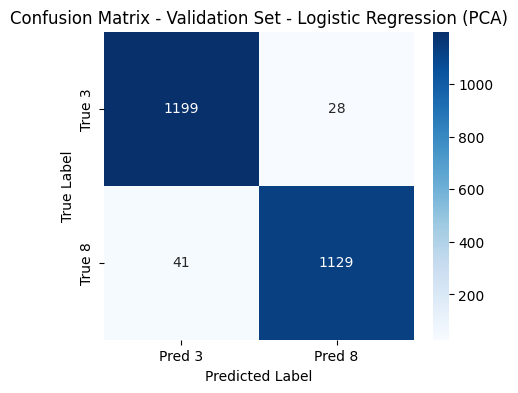

In [91]:
# =========================
# Logistic Regression (PCA)
# =========================

log_reg_pca = LogisticRegressionFromScratch(
    learning_rate=0.1,
    num_iterations=1000
)

log_reg_pca.fit(X_train_pca, y_train)

log_pca_val_results = evaluate_model(
    log_reg_pca,
    X_val_pca,
    y_val,
    dataset_name="Validation Set - Logistic Regression (PCA)"
)

Iteration 0: Loss = 0.693147
Iteration 100: Loss = 0.023178
Iteration 200: Loss = 0.017008
Iteration 300: Loss = 0.014026
Iteration 400: Loss = 0.012132
Iteration 500: Loss = 0.010776
Iteration 600: Loss = 0.009738
Iteration 700: Loss = 0.008910
Iteration 800: Loss = 0.008228
Iteration 900: Loss = 0.007654

Evaluation on Validation Set - Logistic Regression (HOG)
----------------------------------------
Accuracy : 0.9937
Precision: 0.9923
Recall   : 0.9949
F1-score : 0.9936

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      1227
           1       0.99      0.99      0.99      1170

    accuracy                           0.99      2397
   macro avg       0.99      0.99      0.99      2397
weighted avg       0.99      0.99      0.99      2397



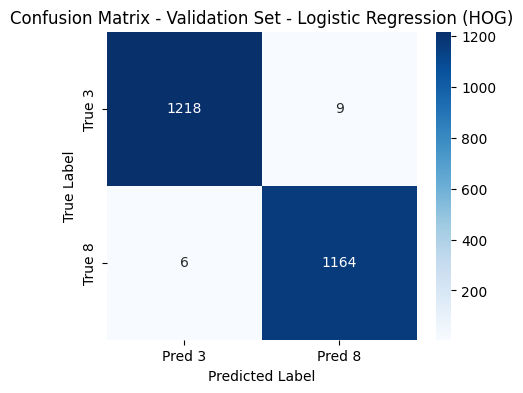

In [92]:
# =========================
# Logistic Regression (HOG)
# =========================

log_reg_hog = LogisticRegressionFromScratch(
    learning_rate=0.1,
    num_iterations=1000
)

log_reg_hog.fit(X_train_hog_scaled, y_train_img)

log_hog_val_results = evaluate_model(
    log_reg_hog,
    X_val_hog_scaled,
    y_val_img,
    dataset_name="Validation Set - Logistic Regression (HOG)"
)

In [93]:
# =========================
# Comparing model of Logistic Regression (3shan nshof anhy a7sn wahed )
# =========================

log_comparison_df = pd.DataFrame([
    {
        "Feature Type": "Raw Pixels",
        "Model": "Logistic Regression",
        **log_val_results
    },
    {
        "Feature Type": "PCA",
        "Model": "Logistic Regression",
        **log_pca_val_results
    },
    {
        "Feature Type": "HOG",
        "Model": "Logistic Regression",
        **log_hog_val_results
    }
])

log_comparison_df = log_comparison_df.sort_values(by="F1-score", ascending=False).reset_index(drop=True)
log_comparison_df

,Feature Type,Model,Accuracy,Precision,Recall,F1-score
0,HOG,Logistic Regression,0.993742,0.992327,0.994872,0.993598
1,Raw Pixels,Logistic Regression,0.972466,0.975043,0.968376,0.971698
2,PCA,Logistic Regression,0.971214,0.975799,0.964957,0.970348


In [94]:
# =========================
# 15A. Simple Logistic Regression Tuning 3shan nkhtar a7sn parameters
# =========================

logreg_results = []

learning_rates = [0.05, 0.1]
iterations_list = [500, 1000]

for lr in learning_rates:
    for iters in iterations_list:
        model = LogisticRegressionFromScratch(
            learning_rate=lr,
            num_iterations=iters
        )

        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_val_scaled)

        logreg_results.append({
            "Model": "Logistic Regression (Scratch)",
            "Learning Rate": lr,
            "Iterations": iters,
            "Accuracy": accuracy_score(y_val, y_pred),
            "Precision": precision_score(y_val, y_pred),
            "Recall": recall_score(y_val, y_pred),
            "F1-score": f1_score(y_val, y_pred)
        })

logreg_results_df = pd.DataFrame(logreg_results)
logreg_results_df = logreg_results_df.sort_values(by="F1-score", ascending=False).reset_index(drop=True)

logreg_results_df

Iteration 0: Loss = 0.693147
Iteration 100: Loss = 0.111717
Iteration 200: Loss = 0.100086
Iteration 300: Loss = 0.095073
Iteration 400: Loss = 0.092020
Iteration 0: Loss = 0.693147
Iteration 100: Loss = 0.111717
Iteration 200: Loss = 0.100086
Iteration 300: Loss = 0.095073
Iteration 400: Loss = 0.092020
Iteration 500: Loss = 0.089869
Iteration 600: Loss = 0.088227
Iteration 700: Loss = 0.086909
Iteration 800: Loss = 0.085813
Iteration 900: Loss = 0.084879
Iteration 0: Loss = 0.693147
Iteration 100: Loss = 0.100000
Iteration 200: Loss = 0.091994
Iteration 300: Loss = 0.088213
Iteration 400: Loss = 0.085804
Iteration 0: Loss = 0.693147
Iteration 100: Loss = 0.100000
Iteration 200: Loss = 0.091994
Iteration 300: Loss = 0.088213
Iteration 400: Loss = 0.085804
Iteration 500: Loss = 0.084060
Iteration 600: Loss = 0.082701
Iteration 700: Loss = 0.081590
Iteration 800: Loss = 0.080653
Iteration 900: Loss = 0.079842


,Model,Learning Rate,Iterations,Accuracy,Precision,Recall,F1-score
0,Logistic Regression (Scratch),0.05,1000,0.972883,0.975883,0.968376,0.972115
1,Logistic Regression (Scratch),0.10,500,0.972883,0.975883,0.968376,0.972115
2,Logistic Regression (Scratch),0.10,1000,0.972466,0.975043,0.968376,0.971698
3,Logistic Regression (Scratch),0.05,500,0.972466,0.975862,0.967521,0.971674


In [95]:
best_lr = logreg_results_df.iloc[0]["Learning Rate"]
best_iters = int(logreg_results_df.iloc[0]["Iterations"])

print("Best Learning Rate:", best_lr)
print("Best Iterations:", best_iters)

Best Learning Rate: 0.05
Best Iterations: 1000


Iteration 0: Loss = 0.693147
Iteration 100: Loss = 0.111717
Iteration 200: Loss = 0.100086
Iteration 300: Loss = 0.095073
Iteration 400: Loss = 0.092020
Iteration 500: Loss = 0.089869
Iteration 600: Loss = 0.088227
Iteration 700: Loss = 0.086909
Iteration 800: Loss = 0.085813
Iteration 900: Loss = 0.084879

Evaluation on Validation Set - Logistic Regression (Raw)
----------------------------------------
Accuracy : 0.9729
Precision: 0.9759
Recall   : 0.9684
F1-score : 0.9721

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.97      1227
           1       0.98      0.97      0.97      1170

    accuracy                           0.97      2397
   macro avg       0.97      0.97      0.97      2397
weighted avg       0.97      0.97      0.97      2397



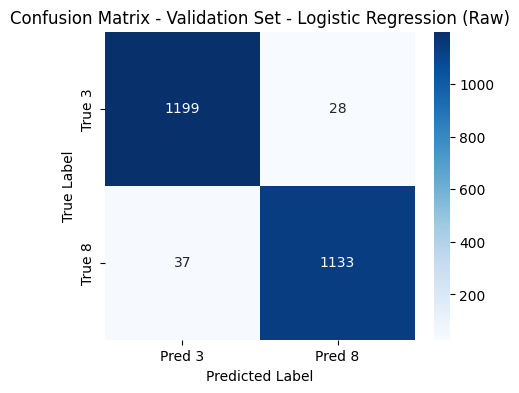

In [96]:
# =========================
# Logistic Regression Raw (Baseline) b3d ma akhtrna a7sn parameters
# =========================

log_reg_raw = LogisticRegressionFromScratch(
    learning_rate=best_lr,
    num_iterations=best_iters
)

log_reg_raw.fit(X_train_scaled, y_train)

log_raw_val_results = evaluate_model(
    log_reg_raw,
    X_val_scaled,
    y_val,
    dataset_name="Validation Set - Logistic Regression (Raw)"
)

Iteration 0: Loss = 0.693147
Iteration 100: Loss = 0.120774
Iteration 200: Loss = 0.111779
Iteration 300: Loss = 0.108575
Iteration 400: Loss = 0.106904
Iteration 500: Loss = 0.105865
Iteration 600: Loss = 0.105154
Iteration 700: Loss = 0.104639
Iteration 800: Loss = 0.104255
Iteration 900: Loss = 0.103959

Evaluation on Validation Set - Logistic Regression (PCA)
----------------------------------------
Accuracy : 0.9708
Precision: 0.9733
Recall   : 0.9667
F1-score : 0.9700

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1227
           1       0.97      0.97      0.97      1170

    accuracy                           0.97      2397
   macro avg       0.97      0.97      0.97      2397
weighted avg       0.97      0.97      0.97      2397



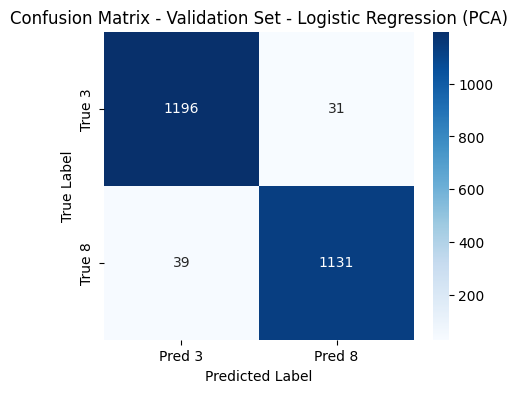

In [97]:
# =========================
# Logistic Regression on PCA Features after tuning
# =========================

log_reg_pca = LogisticRegressionFromScratch(
    learning_rate=best_lr,
    num_iterations=best_iters
)

log_reg_pca.fit(X_train_pca, y_train)

log_pca_val_results = evaluate_model(
    log_reg_pca,
    X_val_pca,
    y_val,
    dataset_name="Validation Set - Logistic Regression (PCA)"
)

Iteration 0: Loss = 0.693147
Iteration 100: Loss = 0.031538
Iteration 200: Loss = 0.023259
Iteration 300: Loss = 0.019420
Iteration 400: Loss = 0.017030
Iteration 500: Loss = 0.015333
Iteration 600: Loss = 0.014036
Iteration 700: Loss = 0.012997
Iteration 800: Loss = 0.012137
Iteration 900: Loss = 0.011408

Evaluation on Validation Set - Logistic Regression (HOG)
----------------------------------------
Accuracy : 0.9946
Precision: 0.9932
Recall   : 0.9957
F1-score : 0.9945

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      1227
           1       0.99      1.00      0.99      1170

    accuracy                           0.99      2397
   macro avg       0.99      0.99      0.99      2397
weighted avg       0.99      0.99      0.99      2397



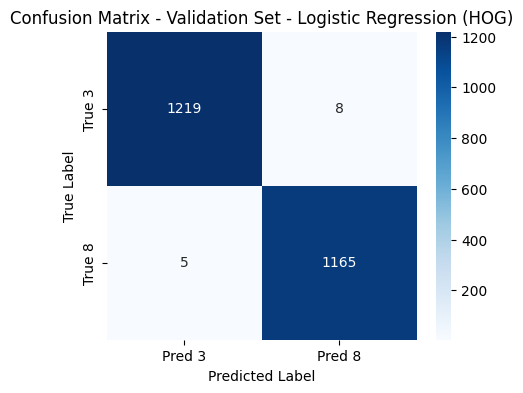

In [98]:
# =========================
# Logistic Regression on HOG Features after tuning
# =========================

log_reg_hog = LogisticRegressionFromScratch(
    learning_rate=best_lr,
    num_iterations=best_iters
)

log_reg_hog.fit(X_train_hog_scaled, y_train_img)

log_hog_val_results = evaluate_model(
    log_reg_hog,
    X_val_hog_scaled,
    y_val_img,
    dataset_name="Validation Set - Logistic Regression (HOG)"
)

In [105]:
# =========================
# Comparing model of Logistic Regression (3shan nshof anhy a7sn wahed b3d ma 3mlna tuning )
# =========================

log_feature_comparison_df = pd.DataFrame([
    {
        "Feature Type": "Raw Pixels",
        "Model": "Logistic Regression",
        **log_raw_val_results
    },
    {
        "Feature Type": "PCA",
        "Model": "Logistic Regression",
        **log_pca_val_results
    },
    {
        "Feature Type": "HOG",
        "Model": "Logistic Regression",
        **log_hog_val_results
    }
])
print("Logistic Regression Comparison (Validation Only):")
log_feature_comparison_df = log_feature_comparison_df.sort_values(by="F1-score", ascending=False).reset_index(drop=True)
log_feature_comparison_df


Logistic Regression Comparison (Validation Only):


,Feature Type,Model,Accuracy,Precision,Recall,F1-score
0,HOG,Logistic Regression,0.994577,0.993180,0.995726,0.994452
1,Raw Pixels,Logistic Regression,0.972883,0.975883,0.968376,0.972115
2,PCA,Logistic Regression,0.970797,0.973322,0.966667,0.969983


In [107]:
best_feature = log_feature_comparison_df.iloc[0]["Feature Type"]
print("Best feature type:", best_feature)

Best feature type: HOG


In [108]:
# Combine train + validation
X_train_val = np.vstack((X_train_scaled, X_val_scaled))
y_train_val = np.hstack((y_train, y_val))

X_train_val_img = np.concatenate((X_train_img, X_val_img), axis=0)
y_train_val_img = np.concatenate((y_train_img, y_val_img), axis=0)

In [109]:
if best_feature == "Raw":
    final_model = LogisticRegressionFromScratch(
        learning_rate=best_lr,
        num_iterations=best_iters
    )
    final_model.fit(X_train_val, y_train_val)
    X_test_final = X_test_scaled


elif best_feature == "PCA":
    from sklearn.decomposition import PCA

    pca_final = PCA(n_components=50, random_state=RANDOM_STATE)
    X_train_val_pca = pca_final.fit_transform(X_train_val)
    X_test_pca = pca_final.transform(X_test_scaled)

    scaler_pca = StandardScaler()
    X_train_val_pca = scaler_pca.fit_transform(X_train_val_pca)
    X_test_final = scaler_pca.transform(X_test_pca)

    final_model = LogisticRegressionFromScratch(
        learning_rate=best_lr,
        num_iterations=best_iters
    )
    final_model.fit(X_train_val_pca, y_train_val)


elif best_feature == "HOG":
    X_train_val_hog = extract_hog_features(X_train_val_img)
    X_test_hog = extract_hog_features(X_test_binary)

    scaler_hog = StandardScaler()
    X_train_val_hog = scaler_hog.fit_transform(X_train_val_hog)
    X_test_final = scaler_hog.transform(X_test_hog)

    final_model = LogisticRegressionFromScratch(
        learning_rate=best_lr,
        num_iterations=best_iters
    )
    final_model.fit(X_train_val_hog, y_train_val_img)

Iteration 0: Loss = 0.693147
Iteration 100: Loss = 0.031892
Iteration 200: Loss = 0.023651
Iteration 300: Loss = 0.019803
Iteration 400: Loss = 0.017406
Iteration 500: Loss = 0.015714
Iteration 600: Loss = 0.014431
Iteration 700: Loss = 0.013408
Iteration 800: Loss = 0.012565
Iteration 900: Loss = 0.011852



Evaluation on Final Logistic Regression (HOG)
----------------------------------------
Accuracy : 0.9940
Precision: 0.9938
Recall   : 0.9938
F1-score : 0.9938

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1010
           1       0.99      0.99      0.99       974

    accuracy                           0.99      1984
   macro avg       0.99      0.99      0.99      1984
weighted avg       0.99      0.99      0.99      1984



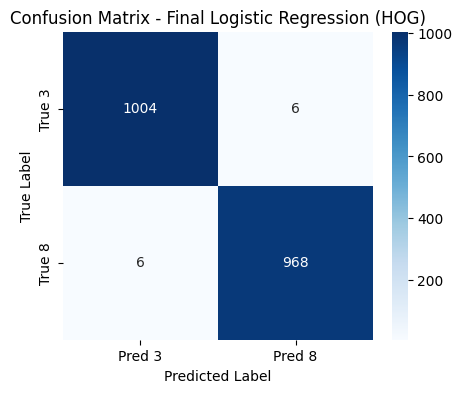


Final Results:
{'Accuracy': 0.9939516129032258, 'Precision': 0.9938398357289527, 'Recall': 0.9938398357289527, 'F1-score': 0.9938398357289527}


In [110]:
final_results = evaluate_model(
    final_model,
    X_test_final,
    y_test_binary,
    dataset_name=f"Final Logistic Regression ({best_feature})"
)

print("\nFinal Results:")
print(final_results)

In [18]:
class KNN:
    def __init__(self, n_neighbors=5):
        """
        Parameters:
        n_neighbors (int): Number of nearest neighbors (k)
        """
        self.k = n_neighbors
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        """
        Store training data (no actual training happens in KNN)
        """
        self.X_train = X
        self.y_train = y

    def _compute_distances(self, X):
        """
        Compute Euclidean distance between each test point and all training points
        Vectorized implementation (FAST)

        Returns:
        distances: shape (num_test_samples, num_train_samples)
        """
        # (x - y)^2 = x^2 + y^2 - 2xy
        X_square = np.sum(X**2, axis=1, keepdims=True)              # (n_test, 1)
        train_square = np.sum(self.X_train**2, axis=1)              # (n_train,)
        cross_term = np.dot(X, self.X_train.T)                      # (n_test, n_train)

        distances = np.sqrt(X_square + train_square - 2 * cross_term)
        return distances

    def predict(self, X):
        """
        Predict labels for input data X
        """
        distances = self._compute_distances(X)

        # Get indices of k nearest neighbors
        k_indices = np.argsort(distances, axis=1)[:, :self.k]

        # Get labels of k nearest neighbors
        k_labels = self.y_train[k_indices]

        # Majority voting
        predictions = np.array([
            Counter(labels).most_common(1)[0][0]
            for labels in k_labels
        ])

        return predictions

    def predict_proba(self, X):
        """
        (Optional) Return probability estimates
        Useful if your project requires confidence scores
        """
        distances = self._compute_distances(X)
        k_indices = np.argsort(distances, axis=1)[:, :self.k]
        k_labels = self.y_train[k_indices]

        probs = []
        for labels in k_labels:
            count = Counter(labels)
            prob_1 = count[1] / self.k
            prob_0 = count[0] / self.k
            probs.append([prob_0, prob_1])

        return np.array(probs)

    def score(self, X, y):
        """
        Return accuracy (same style as sklearn)
        """
        y_pred = self.predict(X)
        return np.mean(y_pred == y)

In [40]:
#KNN tuning 3shan nkhtar a7sn K

knn_results = []

for k in [1, 3, 5, 7, 9]:
    model = KNN(n_neighbors=k)
    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_val_scaled)

    acc = np.mean(y_val == y_pred)

    knn_results.append({
        "Model": "KNN",
        "k": k,
        "Accuracy": acc
    })

import pandas as pd
knn_results_df = pd.DataFrame(knn_results)
knn_results_df


knn_results_df_sorted = knn_results_df.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)
knn_results_df_sorted

,Model,k,Accuracy
0,KNN,5,0.984564
1,KNN,7,0.984147
2,KNN,9,0.983312
3,KNN,3,0.982895
4,KNN,1,0.978306


In [41]:
best_k = knn_results_df.sort_values(by="Accuracy", ascending=False).iloc[0]["k"]
best_k = int(best_k)

print("Best k selected:", best_k)

Best k selected: 5


Best (KNN + Raw) trained successfully.

Evaluation on Validation Set - KNN + Raw
----------------------------------------
Accuracy : 0.9846
Precision: 0.9821
Recall   : 0.9863
F1-score : 0.9842

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      1227
           1       0.98      0.99      0.98      1170

    accuracy                           0.98      2397
   macro avg       0.98      0.98      0.98      2397
weighted avg       0.98      0.98      0.98      2397



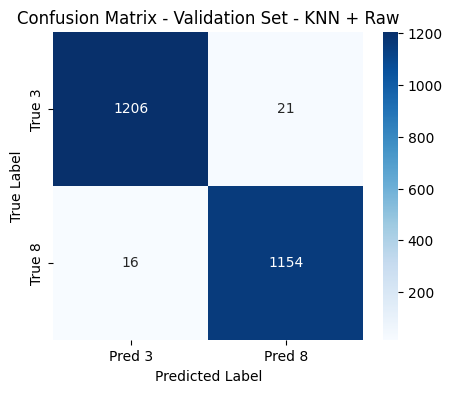

In [58]:
best_knn_Raw = KNN(n_neighbors=best_k)

best_knn_Raw.fit(X_train_scaled, y_train)

print("Best (KNN + Raw) trained successfully.")

knn_val_results = evaluate_model(
    best_knn_Raw,
    X_val_scaled,
    y_val,
    dataset_name="Validation Set - KNN + Raw"
)

Final KNN trained successfully.

Evaluation on Test Set - Final KNN
----------------------------------------
Accuracy : 0.9808
Precision: 0.9835
Recall   : 0.9774
F1-score : 0.9804

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1010
           1       0.98      0.98      0.98       974

    accuracy                           0.98      1984
   macro avg       0.98      0.98      0.98      1984
weighted avg       0.98      0.98      0.98      1984



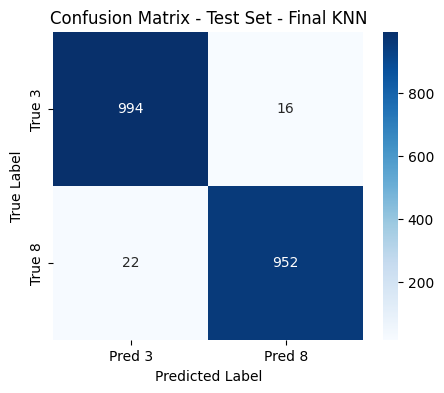

In [47]:
# Wrong pipeline aw code ktbo lmogrd en ashof bs compare maben el models using test data bs dah bio'dy le cheating evaluation
# l2ny hkhtar based on test data w dah biased Evaluation

X_train_final = np.vstack((X_train_scaled, X_val_scaled))
y_train_final = np.hstack((y_train, y_val))

final_knn = KNN(n_neighbors=best_k)
final_knn.fit(X_train_final, y_train_final)

print("Final KNN trained successfully.")

final_test_results = evaluate_model(
    final_knn,
    X_test_scaled,
    y_test_binary,
    dataset_name="Test Set - Final KNN"
)

In [25]:
#KNN + PCA Feature

knn_pca_results = []

for k in [1, 3, 5, 7, 9]:
    model = KNN(n_neighbors=k)
    model.fit(X_train_pca, y_train)

    y_pred = model.predict(X_val_pca)
    acc = np.mean(y_val == y_pred)

    knn_pca_results.append((k, acc))
    print(f"k={k}, Accuracy={acc:.4f}")

best_k_pca = max(knn_pca_results, key=lambda x: x[1])[0]
print("Best k (PCA):", best_k_pca)

k=1, Accuracy=0.9816
k=3, Accuracy=0.9833
k=5, Accuracy=0.9825
k=7, Accuracy=0.9846
k=9, Accuracy=0.9837
Best k (PCA): 7


Best (KNN + PCA) trained successfully.

Evaluation on Validation Set - KNN with PCA
----------------------------------------
Accuracy : 0.9825
Precision: 0.9764
Recall   : 0.9880
F1-score : 0.9822

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      1227
           1       0.98      0.99      0.98      1170

    accuracy                           0.98      2397
   macro avg       0.98      0.98      0.98      2397
weighted avg       0.98      0.98      0.98      2397



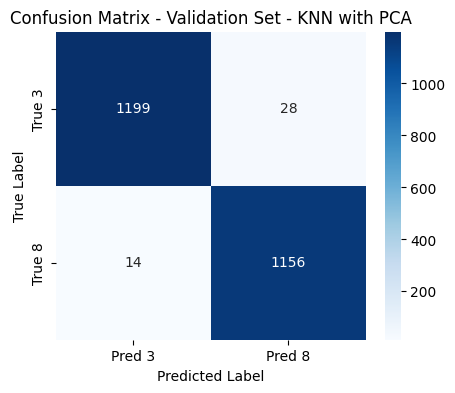

In [50]:
# Train KNN on PCA features
best_knn_pca = KNN(n_neighbors=best_k)
best_knn_pca.fit(X_train_pca, y_train)

print("Best (KNN + PCA) trained successfully.")

# Evaluate on validation
knn_pca_val_results = evaluate_model(
    best_knn_pca,
    X_val_pca,
    y_val,
    dataset_name="Validation Set - KNN with PCA"
)


Evaluation on KNN + PCA (Test)
----------------------------------------
Accuracy : 0.9773
Precision: 0.9764
Recall   : 0.9774
F1-score : 0.9769

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1010
           1       0.98      0.98      0.98       974

    accuracy                           0.98      1984
   macro avg       0.98      0.98      0.98      1984
weighted avg       0.98      0.98      0.98      1984



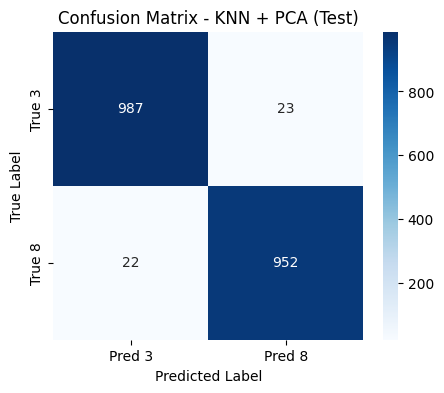

{'Accuracy': 0.9773185483870968,
 'Precision': 0.9764102564102564,
 'Recall': 0.9774127310061602,
 'F1-score': 0.9769112365315546}

In [48]:
# Wrong pipeline aw code ktbo lmogrd en ashof bs compare maben el models using test data bs dah bio'dy le cheating evaluation
# l2ny hkhtar based on test data w dah biased Evaluation

X_train_val_pca = np.vstack((X_train_pca, X_val_pca))
y_train_val = np.hstack((y_train, y_val))

final_knn_pca = KNN(n_neighbors=best_k_pca)
final_knn_pca.fit(X_train_val_pca, y_train_val)

evaluate_model(final_knn_pca, X_test_pca, y_test_binary, "KNN + PCA (Test)")

In [27]:
knn_hog_results = []

for k in [1, 3, 5, 7, 9]:
    model = KNN(n_neighbors=k)
    model.fit(X_train_hog_scaled, y_train_img)

    y_pred = model.predict(X_val_hog_scaled)
    acc = np.mean(y_val == y_pred)

    knn_hog_results.append((k, acc))
    print(f"k={k}, Accuracy={acc:.4f}")

best_k_hog = max(knn_hog_results, key=lambda x: x[1])[0]
print("Best k (HOG):", best_k_hog)

k=1, Accuracy=0.9837
k=3, Accuracy=0.9887
k=5, Accuracy=0.9887
k=7, Accuracy=0.9912
k=9, Accuracy=0.9917
Best k (HOG): 9



Evaluation on Validation Set - KNN + HOG
----------------------------------------
Accuracy : 0.9917
Precision: 0.9881
Recall   : 0.9949
F1-score : 0.9915

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      1227
           1       0.99      0.99      0.99      1170

    accuracy                           0.99      2397
   macro avg       0.99      0.99      0.99      2397
weighted avg       0.99      0.99      0.99      2397



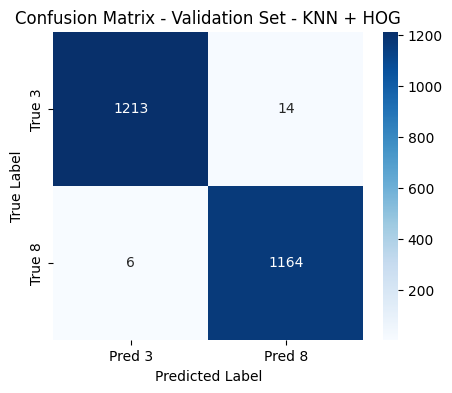

In [28]:
# =========================
# Train Best HOG + KNN and Evaluate
# =========================

best_knn_hog = KNN(n_neighbors=best_k_hog)
best_knn_hog.fit(X_train_hog_scaled, y_train_img)

hog_val_results = evaluate_model(
    best_knn_hog,
    X_val_hog_scaled,
    y_val_img,
    dataset_name="Validation Set - KNN + HOG"
)

In [86]:
# =========================
# Retrain Final knn model (HOG + KNN) on Train + Validation (hwa dah el model el sa7 bs el cell deh btkml el wrong pipeline 3shan el mwdo3 yb2a mow7d fe el tare2a)
# =========================

X_train_val_img = np.concatenate((X_train_img, X_val_img), axis=0)
y_train_val_img = np.concatenate((y_train_img, y_val_img), axis=0)

X_train_val_hog = extract_hog_features(X_train_val_img)
X_train_val_hog_scaled = hog_scaler.fit_transform(X_train_val_hog)

X_test_hog = extract_hog_features(X_test_binary)
X_test_hog_scaled = hog_scaler.transform(X_test_hog)

final_knn_hog = KNN(n_neighbors=best_k_hog)
final_knn_hog.fit(X_train_val_hog_scaled, y_train_val_img)

print(" Final best knn model (KNN + HOG) is trained")


 Final best knn model (KNN + HOG) is trained



Evaluation on KNN Raw
----------------------------------------
Accuracy : 0.9808
Precision: 0.9835
Recall   : 0.9774
F1-score : 0.9804

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1010
           1       0.98      0.98      0.98       974

    accuracy                           0.98      1984
   macro avg       0.98      0.98      0.98      1984
weighted avg       0.98      0.98      0.98      1984



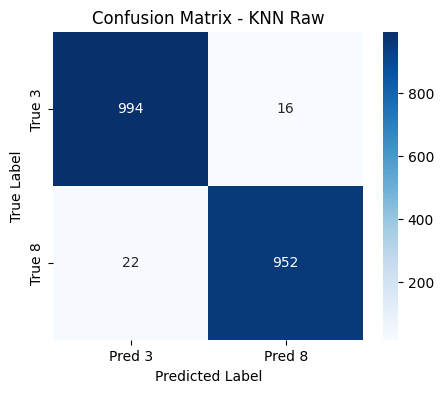


Evaluation on KNN PCA
----------------------------------------
Accuracy : 0.9773
Precision: 0.9764
Recall   : 0.9774
F1-score : 0.9769

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1010
           1       0.98      0.98      0.98       974

    accuracy                           0.98      1984
   macro avg       0.98      0.98      0.98      1984
weighted avg       0.98      0.98      0.98      1984



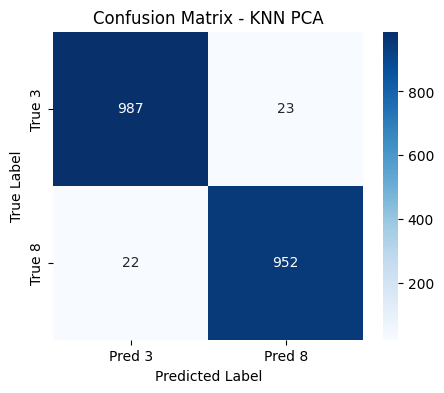


Evaluation on KNN HOG
----------------------------------------
Accuracy : 0.9879
Precision: 0.9837
Recall   : 0.9918
F1-score : 0.9877

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1010
           1       0.98      0.99      0.99       974

    accuracy                           0.99      1984
   macro avg       0.99      0.99      0.99      1984
weighted avg       0.99      0.99      0.99      1984



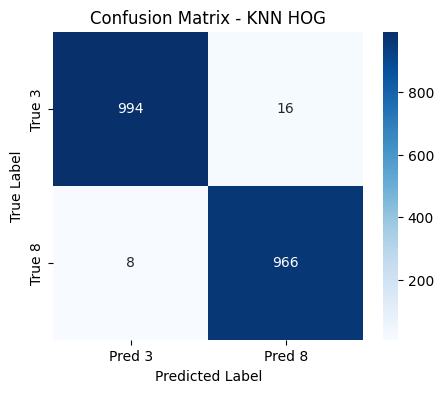

,Feature,Accuracy,Precision,Recall,F1
2,HOG,0.987903,0.983707,0.991786,0.987730
0,Raw,0.980847,0.983471,0.977413,0.980433
1,PCA,0.977319,0.976410,0.977413,0.976911


In [87]:
#Comparision ma ben el models using test data w mn 7zna en el hog tl3 brdo afdl wahed bs msh m3nah en dah el way of comparision el sa7 3shan dah yo3tbr data leakage
# w el test data b2t yo3tbr unseen

results = []

# Raw
raw_results_dict = evaluate_model(final_knn, X_test_scaled, y_test_binary, "KNN Raw")

# PCA
pca_results_dict = evaluate_model(final_knn_pca, X_test_pca, y_test_binary, "KNN PCA")

# HOG
hog_results_dict = evaluate_model(final_knn_hog, X_test_hog_scaled, y_test_binary, "KNN HOG")

results.append(["Raw", raw_results_dict["Accuracy"], raw_results_dict["Precision"], raw_results_dict["Recall"], raw_results_dict["F1-score"]])
results.append(["PCA", pca_results_dict["Accuracy"], pca_results_dict["Precision"], pca_results_dict["Recall"], pca_results_dict["F1-score"]])
results.append(["HOG", hog_results_dict["Accuracy"], hog_results_dict["Precision"], hog_results_dict["Recall"], hog_results_dict["F1-score"]])

import pandas as pd
df = pd.DataFrame(results, columns=["Feature", "Accuracy", "Precision", "Recall", "F1"])
df.sort_values(by="F1", ascending=False)

In [76]:
# =========================
# KNN Comparison (VALIDATION ONLY)
# =========================

knn_comparison_df = pd.DataFrame([
    {
        "Feature Type": "Raw",
        **knn_val_results
    },
    {
        "Feature Type": "PCA",
        **knn_pca_val_results
    },
    {
        "Feature Type": "HOG",
        **hog_val_results
    }
])

# Sort by F1-score (important)
knn_comparison_df = knn_comparison_df.sort_values(
    by="F1-score",
    ascending=False
).reset_index(drop=True)

print("KNN Comparison (Based on Validation Data Only):")
knn_comparison_df

KNN Comparison (Based on Validation Data Only):


,Feature Type,Accuracy,Precision,Recall,F1-score
0,HOG,0.991656,0.988115,0.994872,0.991482
1,Raw,0.984564,0.982128,0.986325,0.984222
2,PCA,0.982478,0.976351,0.988034,0.982158


In [77]:
best_knn_feature = knn_comparison_df.iloc[0]["Feature Type"]

print("Best KNN feature type:", best_knn_feature)

Best KNN feature type: HOG


In [78]:
print("Best KNN feature type:", best_knn_feature)

# =========================
# Final Training (Automatic)
# =========================

if best_knn_feature == "Raw":
    X_train_val = np.vstack((X_train_scaled, X_val_scaled))
    y_train_val = np.hstack((y_train, y_val))

    final_best_knn_model = KNN(n_neighbors=best_k)
    final_best_knn_model.fit(X_train_val, y_train_val)

    X_test_final = X_test_scaled


elif best_knn_feature == "PCA":
    X_train_val = np.vstack((X_train_pca, X_val_pca))
    y_train_val = np.hstack((y_train, y_val))

    final_best_knn_model = KNN(n_neighbors=best_k_pca)
    final_best_knn_model.fit(X_train_val, y_train_val)

    X_test_final = X_test_pca


elif best_knn_feature == "HOG":
    X_train_val_img = np.concatenate((X_train_img, X_val_img), axis=0)
    y_train_val_img = np.concatenate((y_train_img, y_val_img), axis=0)

    X_train_val_hog = extract_hog_features(X_train_val_img)
    X_train_val_hog_scaled = hog_scaler.fit_transform(X_train_val_hog)

    final_best_knn_model = KNN(n_neighbors=best_k_hog)
    final_best_knn_model.fit(X_train_val_hog_scaled, y_train_val_img)

    X_test_final = X_test_hog_scaled


print("Final best KNN model trained automatically based on validation selection")


Best KNN feature type: HOG
Final best KNN model trained automatically based on validation selection



Evaluation on Final KNN (HOG)
----------------------------------------
Accuracy : 0.9879
Precision: 0.9837
Recall   : 0.9918
F1-score : 0.9877

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1010
           1       0.98      0.99      0.99       974

    accuracy                           0.99      1984
   macro avg       0.99      0.99      0.99      1984
weighted avg       0.99      0.99      0.99      1984



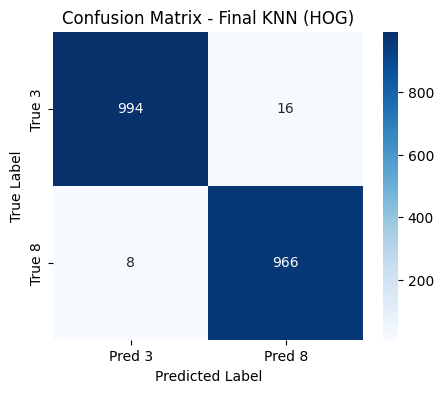


Final KNN Results:
{'Accuracy': 0.9879032258064516, 'Precision': 0.9837067209775967, 'Recall': 0.9917864476386037, 'F1-score': 0.9877300613496932}


In [80]:
# =========================
# Final Test Evaluation (dah el sa7 l2n akhtrna el mdodel based on validation then 3mlna final training (val+training) then we use the test data )
# =========================


final_knn_results = evaluate_model(
    final_best_knn_model,
    X_test_final,
    y_test_binary,
    dataset_name=f"Final KNN ({best_knn_feature})"
)

print("\nFinal KNN Results:")
print(final_knn_results)

In [88]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

def plot_normalized_confusion_matrix(model, X, y_true, title="Normalized Confusion Matrix"):
    y_pred = model.predict(X)

    # Confusion matrix (raw)
    cm = np.array([
        [
            np.sum((y_true == 0) & (y_pred == 0)),  # TN
            np.sum((y_true == 0) & (y_pred == 1))   # FP
        ],
        [
            np.sum((y_true == 1) & (y_pred == 0)),  # FN
            np.sum((y_true == 1) & (y_pred == 1))   # TP
        ]
    ])

    # Normalize (row-wise → percentages per true class)
    cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm_normalized,
        annot=True,
        fmt=".2%",
        cmap="Blues",
        xticklabels=[f"Pred {digit_a}", f"Pred {digit_b}"],
        yticklabels=[f"True {digit_a}", f"True {digit_b}"],
        linewidths=1,
        linecolor="black"
    )

    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    plt.tight_layout()
    plt.show()


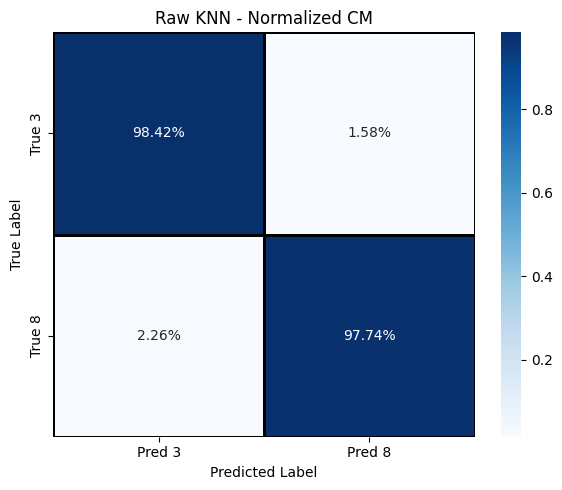

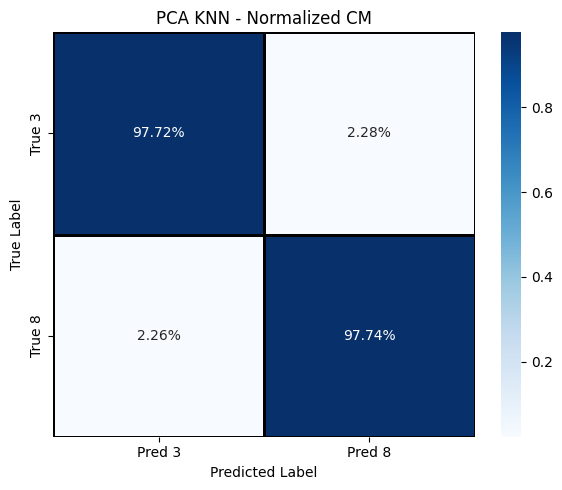

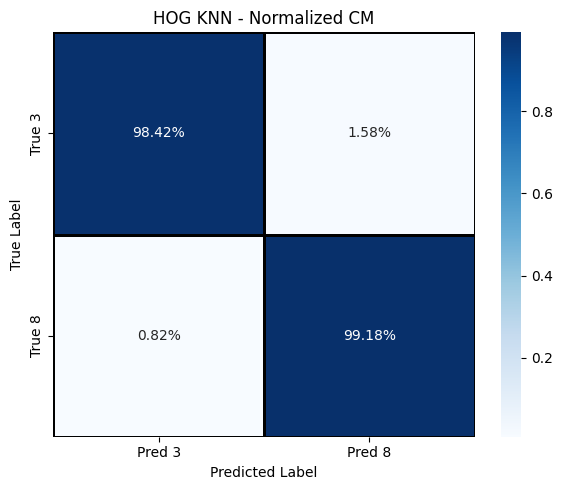

In [89]:
plot_normalized_confusion_matrix(final_knn, X_test_scaled, y_test_binary, "Raw KNN - Normalized CM")
plot_normalized_confusion_matrix(final_knn_pca, X_test_pca, y_test_binary, "PCA KNN - Normalized CM")
plot_normalized_confusion_matrix(final_best_knn_model, X_test_hog_scaled, y_test_binary, "HOG KNN - Normalized CM")

## Linear SVM From Scratch

In this section, Linear Support Vector Machine is implemented from scratch for binary classification between digit 3 and digit 8.

The original labels are 0 and 1, but for SVM they are converted to -1 and +1 because the hinge loss uses the expression y(wᵀx + b).

The model learns two parameters: the weight vector w and the bias b. These define the decision boundary. If wᵀx + b is positive, the image is classified as digit 8. If it is negative, the image is classified as digit 3.

The loss function used is hinge loss with L2 regularization:

L = λ||w||² + (1/n) Σ max(0, 1 - yᵢ(wᵀxᵢ + b))

The model is optimized using gradient descent by updating w and b during training.

In [ ]:
# =========================
# Linear SVM From Scratch
# =========================

class LinearSVMFromScratch:
    def __init__(self, learning_rate=0.0001, lambda_param=0.01, num_iterations=1000):
        self.learning_rate = learning_rate
        self.lambda_param = lambda_param
        self.num_iterations = num_iterations
        self.weights = None
        self.bias = None
        self.loss_history = []

    def compute_loss(self, X, y):
        distances = 1 - y * (np.dot(X, self.weights) + self.bias)
        hinge_loss = np.maximum(0, distances)
        loss = self.lambda_param * np.dot(self.weights, self.weights) + np.mean(hinge_loss)
        return loss

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for iteration in range(self.num_iterations):
            for idx, x_i in enumerate(X):
                condition = y[idx] * (np.dot(x_i, self.weights) + self.bias) >= 1

                if condition:
                    dw = 2 * self.lambda_param * self.weights
                    db = 0
                else:
                    dw = 2 * self.lambda_param * self.weights - y[idx] * x_i
                    db = -y[idx]

                self.weights -= self.learning_rate * dw
                self.bias -= self.learning_rate * db

            loss = self.compute_loss(X, y)
            self.loss_history.append(loss)

            if iteration % 100 == 0:
                print(f"Iteration {iteration}: Loss = {loss:.6f}")

    def predict(self, X):
        output = np.dot(X, self.weights) + self.bias
        predictions = np.where(output >= 0, 1, -1)
        return predictions

In [ ]:
y_train_svm = np.where(y_train == 0, -1, 1)
y_val_svm = np.where(y_val == 0, -1, 1)
y_test_svm = np.where(y_test_binary == 0, -1, 1)

y_train_img_svm = np.where(y_train_img == 0, -1, 1)
y_val_img_svm = np.where(y_val_img == 0, -1, 1)

In [ ]:
# =========================
# SVM Hyperparameter Tuning (HOG only)
# =========================

learning_rates = [0.0001, 0.0005]
lambda_values = [0.001, 0.01, 0.1]

results = []

for lr in learning_rates:
    for lam in lambda_values:
        model = LinearSVMFromScratch(
            learning_rate=lr,
            lambda_param=lam,
            num_iterations=300
        )

        model.fit(X_train_hog_scaled, y_train_img_svm)
        preds = model.predict(X_val_hog_scaled)

        results.append({
            "lr": lr,
            "lambda": lam,
            "f1": f1_score(y_val_img_svm, preds)
        })

tuning_df = pd.DataFrame(results).sort_values(by="f1", ascending=False)
tuning_df

Iteration 0: Loss = 0.028448
Iteration 100: Loss = 0.002111
Iteration 200: Loss = 0.001719
Iteration 0: Loss = 0.030129
Iteration 100: Loss = 0.011524
Iteration 200: Loss = 0.011355
Iteration 0: Loss = 0.044219
Iteration 100: Loss = 0.038294
Iteration 200: Loss = 0.038382
Iteration 0: Loss = 0.016540
Iteration 100: Loss = 0.002149
Iteration 200: Loss = 0.002130
Iteration 0: Loss = 0.020933
Iteration 100: Loss = 0.014252
Iteration 200: Loss = 0.014799
Iteration 0: Loss = 0.046376
Iteration 100: Loss = 0.046214
Iteration 200: Loss = 0.046605


,lr,lambda,f1
1,0.0001,0.010,0.994889
4,0.0005,0.010,0.994456
2,0.0001,0.100,0.993603
5,0.0005,0.100,0.992751
3,0.0005,0.001,0.992744
0,0.0001,0.001,0.992327


Iteration 0: Loss = 0.109219
Iteration 100: Loss = 0.079207
Iteration 200: Loss = 0.079163
Iteration 300: Loss = 0.079094
Iteration 400: Loss = 0.079250
Iteration 500: Loss = 0.079361
Iteration 600: Loss = 0.079276
Iteration 700: Loss = 0.079256
Iteration 800: Loss = 0.079178
Iteration 900: Loss = 0.079199

Evaluation on Validation Set - Linear SVM From Scratch Raw
----------------------------------------
Accuracy : 0.9708
Precision: 0.9750
Recall   : 0.9650
F1-score : 0.9699

Classification Report:
              precision    recall  f1-score   support

          -1       0.97      0.98      0.97      1227
           1       0.97      0.96      0.97      1170

    accuracy                           0.97      2397
   macro avg       0.97      0.97      0.97      2397
weighted avg       0.97      0.97      0.97      2397



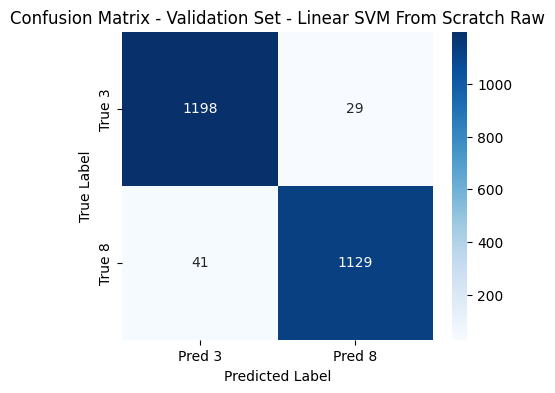

In [ ]:
# Raw Pixels
svm_raw = LinearSVMFromScratch(
    learning_rate=0.0001,
    lambda_param=0.01,
    num_iterations=1000
)

svm_raw.fit(X_train_scaled, y_train_svm)

svm_raw_val_results =evaluate_model(
    svm_raw,
    X_val_scaled,
    y_val_svm,
    dataset_name="Validation Set - Linear SVM From Scratch Raw"
)

Iteration 0: Loss = 0.121336
Iteration 100: Loss = 0.101854
Iteration 200: Loss = 0.101854
Iteration 300: Loss = 0.101785
Iteration 400: Loss = 0.101885
Iteration 500: Loss = 0.101806
Iteration 600: Loss = 0.101819
Iteration 700: Loss = 0.101765
Iteration 800: Loss = 0.101862
Iteration 900: Loss = 0.101757

Evaluation on Validation Set - Linear SVM From Scratch PCA
----------------------------------------
Accuracy : 0.9712
Precision: 0.9758
Recall   : 0.9650
F1-score : 0.9703

Classification Report:
              precision    recall  f1-score   support

          -1       0.97      0.98      0.97      1227
           1       0.98      0.96      0.97      1170

    accuracy                           0.97      2397
   macro avg       0.97      0.97      0.97      2397
weighted avg       0.97      0.97      0.97      2397



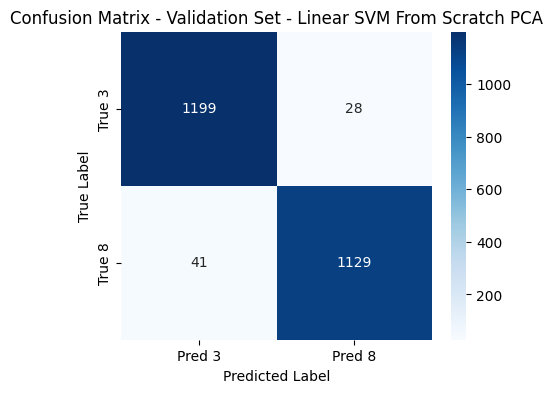

In [ ]:
# PCA Features
svm_pca = LinearSVMFromScratch(
    learning_rate=0.0001,
    lambda_param=0.01,
    num_iterations=1000
)

svm_pca.fit(X_train_pca, y_train_svm)

svm_pca_val_results = evaluate_model(
    svm_pca,
    X_val_pca,
    y_val_svm,
    dataset_name="Validation Set - Linear SVM From Scratch PCA"
)

Iteration 0: Loss = 0.030129
Iteration 100: Loss = 0.011524
Iteration 200: Loss = 0.011355
Iteration 300: Loss = 0.011258
Iteration 400: Loss = 0.011320
Iteration 500: Loss = 0.011259
Iteration 600: Loss = 0.011345
Iteration 700: Loss = 0.011448
Iteration 800: Loss = 0.011356
Iteration 900: Loss = 0.011298

Evaluation on Validation Set - Linear SVM From Scratch HOG
----------------------------------------
Accuracy : 0.9950
Precision: 0.9915
Recall   : 0.9983
F1-score : 0.9949

Classification Report:
              precision    recall  f1-score   support

          -1       1.00      0.99      1.00      1227
           1       0.99      1.00      0.99      1170

    accuracy                           0.99      2397
   macro avg       0.99      1.00      0.99      2397
weighted avg       1.00      0.99      0.99      2397



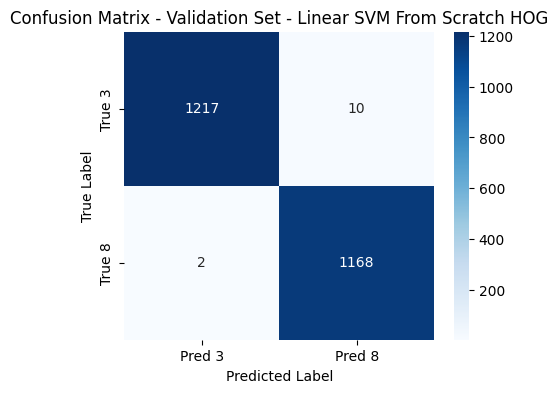

In [ ]:
# HOG Features
svm_hog = LinearSVMFromScratch(
    learning_rate=0.0001,
    lambda_param=0.01,
    num_iterations=1000
)

svm_hog.fit(X_train_hog_scaled, y_train_img_svm)

svm_hog_val_results = evaluate_model(
    svm_hog,
    X_val_hog_scaled,
    y_val_img_svm,
    dataset_name="Validation Set - Linear SVM From Scratch HOG"
)

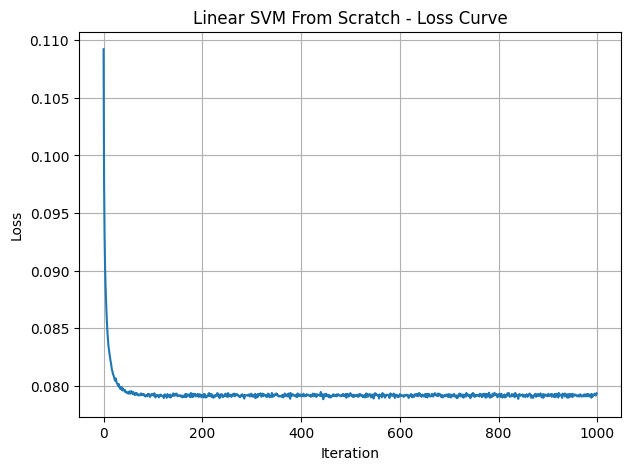

In [ ]:
plt.figure(figsize=(7, 5))
plt.plot(svm_raw.loss_history)
plt.title("Linear SVM From Scratch - Loss Curve")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

Iteration 0: Loss = 0.029108
Iteration 100: Loss = 0.012187
Iteration 200: Loss = 0.012143
Iteration 300: Loss = 0.012094
Iteration 400: Loss = 0.012132

Evaluation on Test Set - Final Linear SVM From Scratch HOG
----------------------------------------
Accuracy : 0.9929
Precision: 0.9959
Recall   : 0.9897
F1-score : 0.9928

Classification Report:
              precision    recall  f1-score   support

          -1       0.99      1.00      0.99      1010
           1       1.00      0.99      0.99       974

    accuracy                           0.99      1984
   macro avg       0.99      0.99      0.99      1984
weighted avg       0.99      0.99      0.99      1984



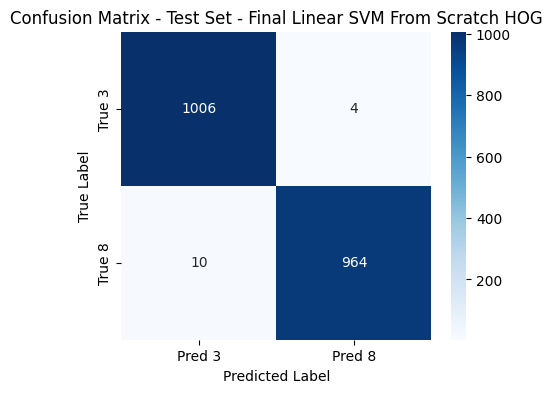

In [ ]:
X_train_val_hog_svm = np.vstack((X_train_hog_scaled, X_val_hog_scaled))
y_train_val_hog_svm = np.hstack((y_train_img_svm, y_val_img_svm))

best_lr = tuning_df.iloc[0]["lr"]
best_lambda = tuning_df.iloc[0]["lambda"]

final_svm_hog = LinearSVMFromScratch(
    learning_rate=best_lr,
    lambda_param=best_lambda,
    num_iterations=500
)

# IMPORTANT: train the model before evaluation
final_svm_hog.fit(X_train_val_hog_svm, y_train_val_hog_svm)

svm_hog_test_results =  evaluate_model(
    final_svm_hog,
    X_test_hog_scaled,
    y_test_svm,
    dataset_name="Test Set - Final Linear SVM From Scratch HOG"
)

Iteration 0: Loss = 0.029108
Iteration 100: Loss = 0.012187
Iteration 200: Loss = 0.012143
Iteration 300: Loss = 0.012094
Iteration 400: Loss = 0.012132

Evaluation on Test Set - Final Linear SVM (HOG)
----------------------------------------
Accuracy : 0.9929
Precision: 0.9959
Recall   : 0.9897
F1-score : 0.9928

Classification Report:
              precision    recall  f1-score   support

          -1       0.99      1.00      0.99      1010
           1       1.00      0.99      0.99       974

    accuracy                           0.99      1984
   macro avg       0.99      0.99      0.99      1984
weighted avg       0.99      0.99      0.99      1984



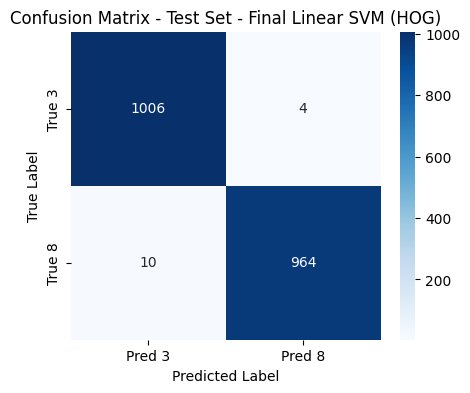

In [ ]:
# =========================
# Final SVM (HOG) - Train on Train + Validation, Test on Test Set
# =========================

# Combine train + validation
X_train_val_hog_svm = np.vstack((X_train_hog_scaled, X_val_hog_scaled))
y_train_val_hog_svm = np.hstack((y_train_img_svm, y_val_img_svm))

# Get best hyperparameters from tuning
best_lr = tuning_df.iloc[0]["lr"]
best_lambda = tuning_df.iloc[0]["lambda"]

# Create final model using best parameters
final_svm_hog = LinearSVMFromScratch(
    learning_rate=best_lr,
    lambda_param=best_lambda,
    num_iterations=500
)

# Train
final_svm_hog.fit(X_train_val_hog_svm, y_train_val_hog_svm)

# Evaluate on test set
svm_hog_test_results = evaluate_model(
    final_svm_hog,
    X_test_hog_scaled,
    y_test_svm,
    dataset_name="Test Set - Final Linear SVM (HOG)"
)

##Final Comparision Model to Choose the best model bs based on validation (Right Pipeline)

In [ ]:
# =========================
# Collect ALL validation results
# =========================

all_models_results = pd.DataFrame([
    # KNN
    {"Model": "KNN (Raw)", **knn_val_results},
    {"Model": "KNN (PCA)", **knn_pca_val_results},
    {"Model": "KNN (HOG)", **hog_val_results},

    # Logistic Regression
    {"Model": "LogReg (Raw)", **log_raw_val_results},
    {"Model": "LogReg (PCA)", **log_pca_val_results},
    {"Model": "LogReg (HOG)", **log_hog_val_results},

    # SVM
    {"Model": "SVM (Raw)", **svm_raw_val_results},
    {"Model": "SVM (PCA)", **svm_pca_val_results},
    {"Model": "SVM (HOG)", **svm_hog_val_results},
])

# Sort by F1-score
all_models_results = all_models_results.sort_values(by="F1-score", ascending=False).reset_index(drop=True)

all_models_results

,Model,Accuracy,Precision,Recall,F1-score
0,SVM (HOG),0.994994,0.991511,0.998291,0.994889
1,LogReg (HOG),0.994577,0.993180,0.995726,0.994452
2,KNN (HOG),0.991656,0.988115,0.994872,0.991482
3,KNN (Raw),0.982895,0.981245,0.983761,0.982501
4,KNN (PCA),0.982478,0.976351,0.988034,0.982158
5,LogReg (Raw),0.972883,0.975883,0.968376,0.972115
6,SVM (PCA),0.971214,0.975799,0.964957,0.970348
7,LogReg (PCA),0.970797,0.973322,0.966667,0.969983
8,SVM (Raw),0.970797,0.974957,0.964957,0.969931


In [ ]:
best_model_name = all_models_results.iloc[0]["Model"]
print("Best model based on validation:", best_model_name)

Best model based on validation: SVM (HOG)


In [ ]:
# Dictionary mapping names to trained FINAL models
model_dict = {
    "KNN (Raw)": final_knn,
    "KNN (PCA)": final_knn_pca,
    "KNN (HOG)": final_knn_hog,

    "LogReg (Raw)": log_reg_raw,
    "LogReg (PCA)": log_reg_pca,
    "LogReg (HOG)": log_reg_hog,

    "SVM (Raw)": svm_raw,
    "SVM (PCA)": svm_pca,
    "SVM (HOG)": final_svm_hog
}

best_model = model_dict[best_model_name]

In [ ]:
if "Raw" in best_model_name:
    X_test_final = X_test_scaled

elif "PCA" in best_model_name:
    X_test_final = X_test_pca

elif "HOG" in best_model_name:
    X_test_final = X_test_hog_scaled


Evaluation on Final Test - SVM (HOG)
----------------------------------------
Accuracy : 0.9929
Precision: 0.9959
Recall   : 0.9897
F1-score : 0.9928

Classification Report:
              precision    recall  f1-score   support

          -1       0.99      1.00      0.99      1010
           1       1.00      0.99      0.99       974

    accuracy                           0.99      1984
   macro avg       0.99      0.99      0.99      1984
weighted avg       0.99      0.99      0.99      1984



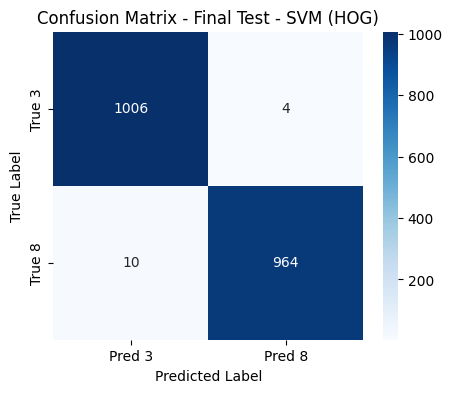

Final Selected Model Results:
{'Accuracy': 0.9929435483870968, 'Precision': 0.9958677685950413, 'Recall': 0.9897330595482546, 'F1-score': 0.9927909371781668}


In [ ]:
final_results = evaluate_model(
    best_model,
    X_test_final,
    y_test_binary if "SVM" not in best_model_name else y_test_svm,
    dataset_name=f"Final Test - {best_model_name}"
)

print("Final Selected Model Results:")
print(final_results)